## $S_8$ Whisker Plot

This notebook creates a whisker plot of $S_8$ values for different test cases and external datasets.

In [3]:
import matplotlib
from astropy.io import fits
import matplotlib.pyplot as plt
import uncertainties
import yaml
import os
import numpy as np

plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({'font.size': 25})
plt.rc('mathtext', fontset='stix')
plt.rc('font', family='serif')

chains_dir = f"/n09data/guerrini/output_chains/"
num_test_cases = 1


In [5]:
# Read in text file with s8 values for the different test cases and external experiments 
# (have had to run getdist to analyse the chains first)

s8s = np.loadtxt(f"{chains_dir}/S8_means.txt",dtype={'names': ('Expt', 's8_mean', 's8_low', 's8_high'), 'formats': ('U40', 'U20', 'U20', 'U20')}, skiprows=1, delimiter=',')
expt = s8s['Expt']
s8s_mean = s8s['s8_mean'].astype(np.float64)
s8s_low = s8s['s8_low'].astype(np.float64)
s8s_high = s8s['s8_high'].astype(np.float64)

(0.0, 4.0)

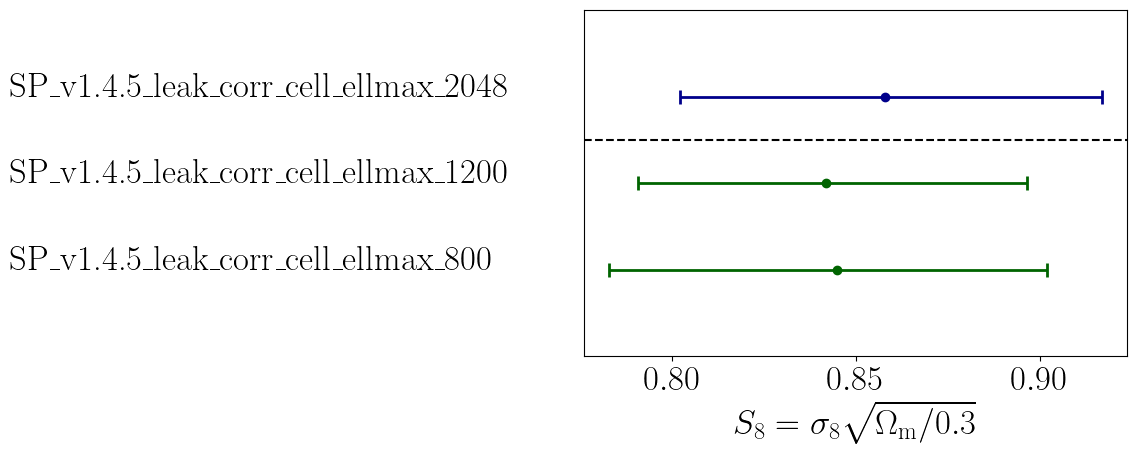

In [23]:

fig, axs = plt.subplots(1, 1, sharey=True, figsize=[7,1.5*len(expt)])
axs.yaxis.set_visible(False)

y = np.arange(0,len(expt))

for i in y:
    if i > len(expt)-num_test_cases-1:
        axs.errorbar(s8s_mean[i], i+1, xerr=np.vstack((s8s_low[i],s8s_high[i])), fmt='o', c = 'darkblue',lw = 2, capsize=5,capthick=2)
    else:
        axs.errorbar(s8s_mean[i], i+1, xerr=np.vstack((s8s_low[i],s8s_high[i])), fmt='o', c = 'darkgreen',lw = 2, capsize=5,capthick=2)
        
    """ if i == 0:        # Plot the band for "Planck"
        axs.axvspan(s8s_mean[i]-s8s_low[i], s8s_mean[i]+s8s_high[i], alpha=0.2, color='cyan')
    if i == len(expt)-1:        # Plot the band for "this work"
        axs.axvspan(s8s_mean[i]-s8s_low[i], s8s_mean[i]+s8s_high[i], alpha=0.2, color='lightpink')"""
    if i == len(expt)-num_test_cases-1: # Make a distinction between this work (and all its test cases) with external datasets
        axs.axhline(i+1.5, ls='dashed',c='k') 
    
    
    axs.set_xlabel(r'$S_8=\sigma_8\sqrt{\Omega_{\rm m}/0.3}$')    
    axs.text(0.62, i+1, rf"{expt[i]}")

plt.ylim([0,i+2])
# plt.savefig('plots/s8_whisker.pdf',bbox_inches="tight")

In [8]:
def compute_sigma_shift(s8_1, s8_2, s8_1_low, s8_1_high, s8_2_low, s8_2_high):
    """ Compute the tension between two measurements of S8 given their 1-sigma errorbars.
        The errorbars can be asymmetric.
        The tension is computed as the distance between the two measurements divided by the sum in quadrature of the 1-sigma errorbars.
        If the errorbars are asymmetric, we use the errorbar that is in the direction of the other measurement.
    """
    if s8_1 < s8_2:
        sigma_1 = s8_1_high
        sigma_2 = s8_2_low
    else:
        sigma_1 = s8_1_low
        sigma_2 = s8_2_high
    sigma_shift = (s8_2 - s8_1) / np.sqrt(sigma_1**2 + sigma_2**2)
    return sigma_shift

In [13]:
def compute_matrix_sigma_shift(expt):
    """ Compute the tension between all measurements of S8 and the reference measurement (first one).
    """
    tensions = np.zeros((len(expt), len(expt)))
    for i in range(len(expt)):
        for j in range(len(expt)):
            if i != j:
                sigma_shift = compute_sigma_shift(s8s_mean[i], s8s_mean[j], s8s_low[i], s8s_high[i], s8s_low[j], s8s_high[j])
                tensions[i, j] = sigma_shift
    return tensions

In [14]:
tensions = compute_matrix_sigma_shift(expt)

<Figure size 640x480 with 0 Axes>

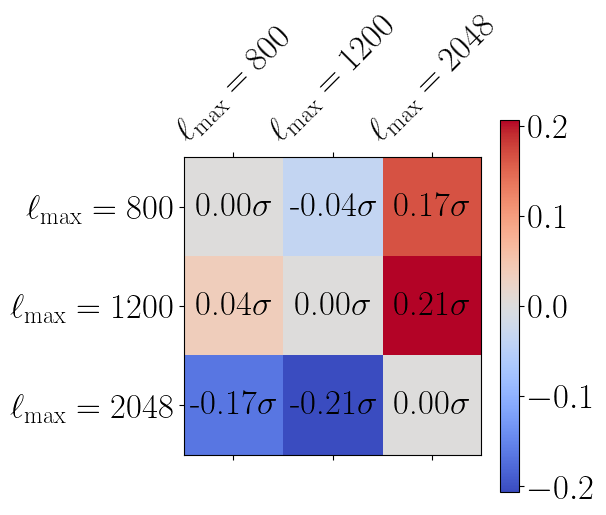

In [22]:
plt.figure()

plt.matshow(tensions, cmap='coolwarm')
plt.colorbar()

# Add values on top of each cell
for (i, j), val in np.ndenumerate(tensions):
    plt.text(j, i, f"{val:.2f}$\\sigma$", ha='center', va='center', color='black')

labels = [f"$\ell_\mathrm{{max}}={i}$" for i in [800, 1200, 2048]]
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

plt.show()